# Task 1:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Parrot.png is not provided, so use the included Chelsea image.
image = cv2.imread("chelsea.png")

if image is None:
    raise FileNotFoundError("Image could not be loaded.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

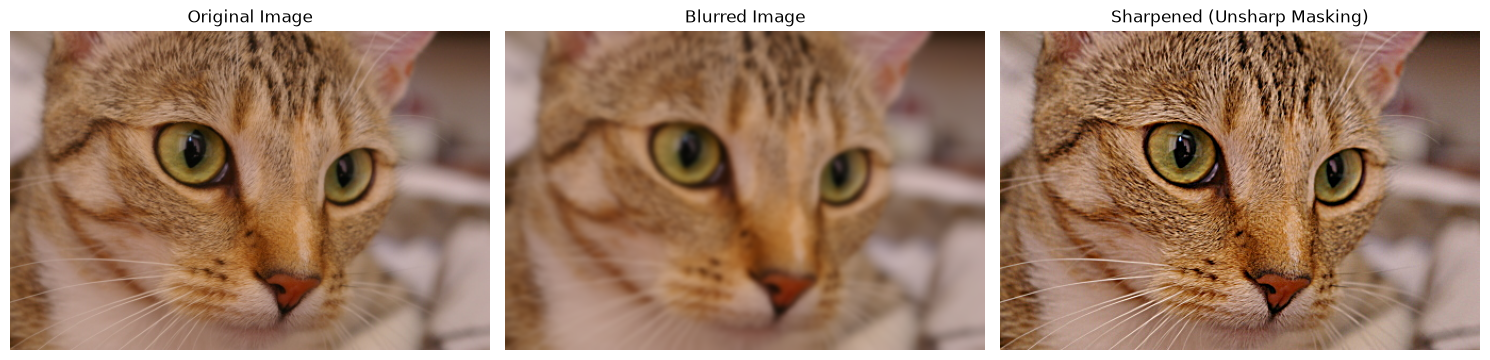

In [2]:
# Gaussian sigma and sharpening amount
sigma = 2
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.tight_layout()
plt.show()

# Assessment Task 1:

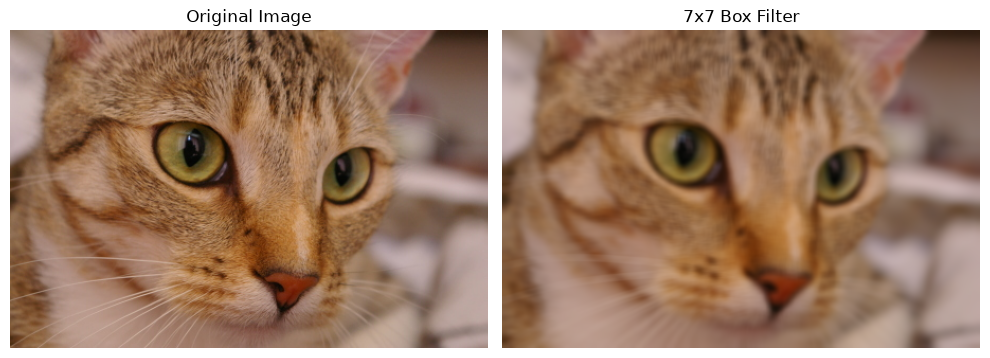

In [3]:
# Convolve the image with a normalized 7x7 box filter
box_filter = np.ones((7, 7), dtype=np.float32) / 49.0
box_smoothed = cv2.filter2D(image_float, -1, box_filter)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(box_smoothed)
ax[1].set_title("7x7 Box Filter")
ax[1].axis("off")
plt.tight_layout()
plt.show()

# Assessment Task 2:

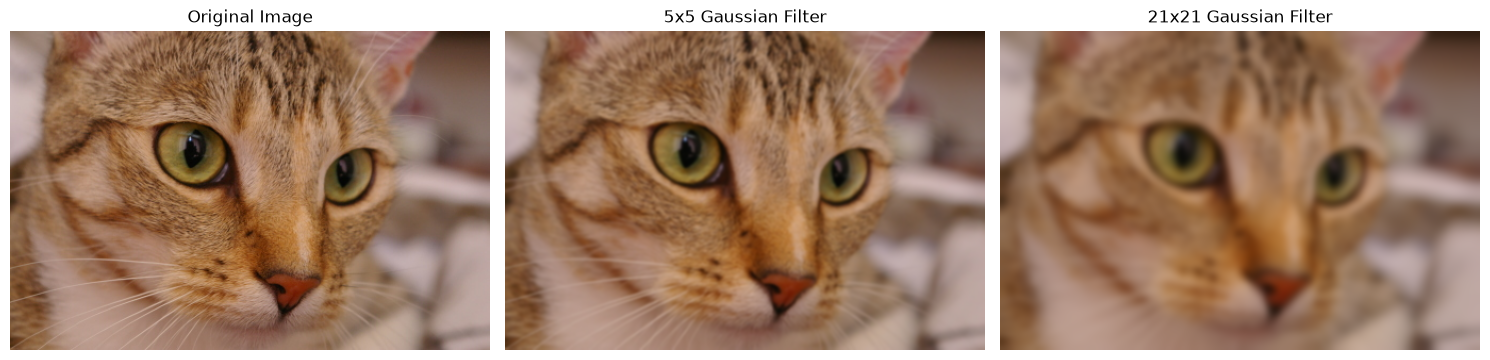

In [4]:
# Apply 5x5 and 21x21 Gaussian filters
gaussian_5 = cv2.GaussianBlur(image_float, (5, 5), 0)
gaussian_21 = cv2.GaussianBlur(image_float, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(gaussian_5)
ax[1].set_title("5x5 Gaussian Filter")
ax[1].axis("off")
ax[2].imshow(gaussian_21)
ax[2].set_title("21x21 Gaussian Filter")
ax[2].axis("off")
plt.tight_layout()
plt.show()

# Assessment Task 3:

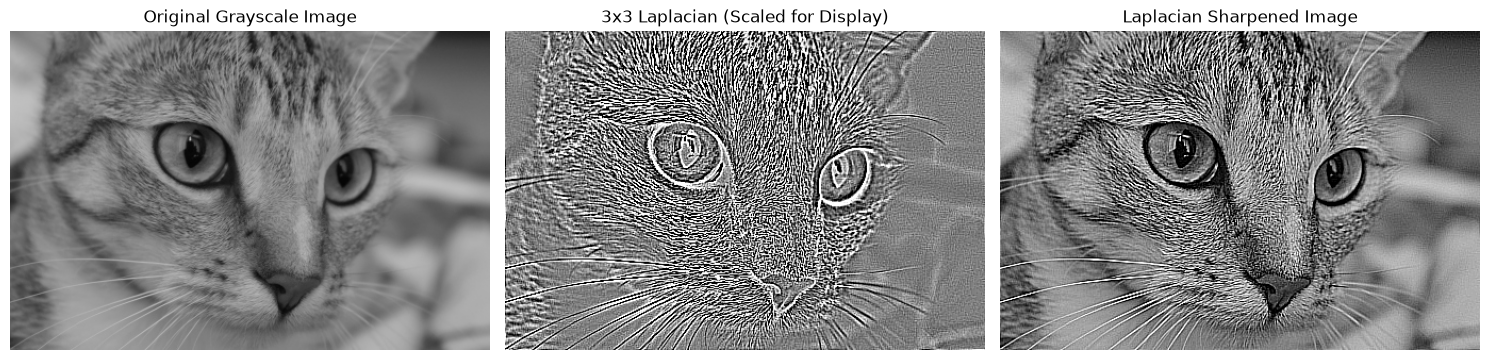

In [5]:
# Convert to grayscale and float32 before applying the 3x3 Laplacian
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
gray_float = gray_image.astype(np.float32) / 255.0

laplacian = cv2.Laplacian(gray_float, cv2.CV_32F, ksize=3)
laplacian_sharpened = np.clip(gray_float - laplacian, 0, 1)

# Scale the signed Laplacian around mid-gray so its edges are visible.
laplacian_display = np.clip(0.5 + laplacian * 3, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(gray_image, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original Grayscale Image")
ax[0].axis("off")
ax[1].imshow(laplacian_display, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("3x3 Laplacian (Scaled for Display)")
ax[1].axis("off")
ax[2].imshow(laplacian_sharpened, cmap="gray", vmin=0, vmax=1)
ax[2].set_title("Laplacian Sharpened Image")
ax[2].axis("off")
plt.tight_layout()
plt.show()